# 04 Analysis

This notebook is the single place for all Part D work: final model comparison, ablation summaries, figure references, error analysis, and written discussion prompts.

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from src.evaluate import build_summary_table


## Paste Exported Results

Paste the best MLP result from `02_mlp.ipynb` and the recurrent export payloads from `03_rnn.ipynb` below.

In [2]:
CHECKPOINT_DIR = Path("../checkpoints")
MLP_EXPORT_PATH = CHECKPOINT_DIR / "mlp_best_result.json"
RECURRENT_EXPORT_PATH = CHECKPOINT_DIR / "recurrent_exports.json"
MISCLASSIFIED_PATH = CHECKPOINT_DIR / "best_model_misclassified_examples.csv"

mlp_best_result = {
    "model": "MLP (best configuration)",
    "variant": "mlp",
    "accuracy": 0.0,
    "precision": 0.0,
    "recall": 0.0,
    "f1": 0.0,
    "time_per_epoch_sec": 0.0,
    "checkpoint_path": "../checkpoints/mlp_best.pt",
    "figure_path": "../checkpoints/figures/mlp_baseline_learning_curves.png",
}

if MLP_EXPORT_PATH.exists():
    mlp_best_result = json.loads(MLP_EXPORT_PATH.read_text())

recurrent_results_export = []
embedding_ablation_export = []
layer_ablation_export = []
figure_paths_export = {
    "variant_comparison": [],
    "embedding_ablation": [],
    "layer_ablation": [],
}

if RECURRENT_EXPORT_PATH.exists():
    recurrent_payload = json.loads(RECURRENT_EXPORT_PATH.read_text())
    recurrent_results_export = recurrent_payload.get("recurrent_results_export", [])
    embedding_ablation_export = recurrent_payload.get("embedding_ablation_export", [])
    layer_ablation_export = recurrent_payload.get("layer_ablation_export", [])
    figure_paths_export = recurrent_payload.get("figure_paths_export", figure_paths_export)

{
    "mlp_best_result": mlp_best_result,
    "recurrent_results_export": recurrent_results_export,
    "embedding_ablation_export_rows": len(embedding_ablation_export),
    "layer_ablation_export_rows": len(layer_ablation_export),
}


{'mlp_best_result': {'model': 'MLP (best configuration)',
  'variant': 'mlp',
  'accuracy': 0.88,
  'precision': 0.861904761904762,
  'recall': 0.905,
  'f1': 0.8829268292682927,
  'time_per_epoch_sec': 2.4971044063568115,
  'checkpoint_path': '../checkpoints/mlp_best.pt',
  'figure_path': '../checkpoints/figures/depth_3_learning_curves.png',
  'run': 'depth_3',
  'embed_dim': 128,
  'hidden_dims': [256, 128, 64],
  'dropout': 0.3,
  'parameter_count': 3914306},
 'recurrent_results_export': [{'model': 'Vanilla RNN',
   'variant': 'rnn',
   'accuracy': 0.6677,
   'precision': 0.6756020942408377,
   'recall': 0.6452,
   'f1': 0.6600511508951407,
   'time_per_epoch_sec': 115.84443195660909,
   'checkpoint_path': '/Users/admin/Downloads/New project/checkpoints/rnn_best.pt',
   'figure_path': '/Users/admin/Downloads/New project/checkpoints/figures/rnn_learning_curves.png'},
  {'model': 'LSTM',
   'variant': 'lstm',
   'accuracy': 0.7757,
   'precision': 0.7690806168260784,
   'recall': 0.78

## Final Comparison Table

In [3]:
combined_results = [mlp_best_result] + recurrent_results_export
results_df = pd.DataFrame(combined_results)
summary_df = build_summary_table(results_df) if not results_df.empty else pd.DataFrame()
summary_df


,Model,Acc.,Prec.,Recall,F1,Time/epoch
0,MLP (best configuration),0.8800,0.8619,0.9050,0.8829,2.50
1,Vanilla RNN,0.6677,0.6756,0.6452,0.6601,115.84
2,LSTM,0.7757,0.7691,0.7880,0.7784,135.38
3,GRU,0.8268,0.7839,0.9024,0.8390,145.57


## Best Model

In [4]:
best_model_row = results_df.sort_values("accuracy", ascending=False).iloc[0] if not results_df.empty else None
best_model_row


model                                          MLP (best configuration)
variant                                                             mlp
accuracy                                                           0.88
precision                                                      0.861905
recall                                                            0.905
f1                                                             0.882927
time_per_epoch_sec                                             2.497104
checkpoint_path                              ../checkpoints/mlp_best.pt
figure_path           ../checkpoints/figures/depth_3_learning_curves...
run                                                             depth_3
embed_dim                                                         128.0
hidden_dims                                              [256, 128, 64]
dropout                                                             0.3
parameter_count                                               39

## Ablation Summaries

In [5]:
embedding_ablation_df = pd.DataFrame(embedding_ablation_export)
layer_ablation_df = pd.DataFrame(layer_ablation_export)

print("Embedding dimension ablation")
display(embedding_ablation_df)

print("Recurrent layer ablation")
display(layer_ablation_df)


Embedding dimension ablation


,model,variant,embed_dim,accuracy,precision,recall,f1,time_per_epoch_sec,checkpoint_path,figure_path
0,GRU,gru,64,0.8550,0.840691,0.8760,0.857982,122.813716,/Users/admin/Downloads/New project/checkpoints...,/Users/admin/Downloads/New project/checkpoints...
1,GRU,gru,128,0.8191,0.776660,0.8958,0.831987,141.953526,/Users/admin/Downloads/New project/checkpoints...,/Users/admin/Downloads/New project/checkpoints...
2,GRU,gru,256,0.8394,0.827101,0.8582,0.842364,221.449593,/Users/admin/Downloads/New project/checkpoints...,/Users/admin/Downloads/New project/checkpoints...


Recurrent layer ablation


,model,variant,num_layers,accuracy,precision,recall,f1,time_per_epoch_sec,checkpoint_path,figure_path
0,GRU,gru,1,0.8102,0.757470,0.9126,0.827830,144.089294,/Users/admin/Downloads/New project/checkpoints...,/Users/admin/Downloads/New project/checkpoints...
1,GRU,gru,2,0.8767,0.843516,0.9250,0.882381,320.993970,/Users/admin/Downloads/New project/checkpoints...,/Users/admin/Downloads/New project/checkpoints...


## Learning Curves

Use the saved figure paths from Parts B and C. Display at least two models with noticeably different behaviour in your final discussion.

In [6]:
mlp_figure_paths = [mlp_best_result.get("figure_path", "")]

all_curve_paths = [path for path in mlp_figure_paths if path]
for group in figure_paths_export.values():
    all_curve_paths.extend(item["figure_path"] for item in group)

pd.DataFrame({"figure_path": all_curve_paths})


,figure_path
0,../checkpoints/figures/depth_3_learning_curves...
1,/Users/admin/Downloads/New project/checkpoints...
2,/Users/admin/Downloads/New project/checkpoints...
3,/Users/admin/Downloads/New project/checkpoints...
4,/Users/admin/Downloads/New project/checkpoints...
5,/Users/admin/Downloads/New project/checkpoints...
6,/Users/admin/Downloads/New project/checkpoints...
7,/Users/admin/Downloads/New project/checkpoints...
8,/Users/admin/Downloads/New project/checkpoints...


../checkpoints/figures/depth_3_learning_curves.png


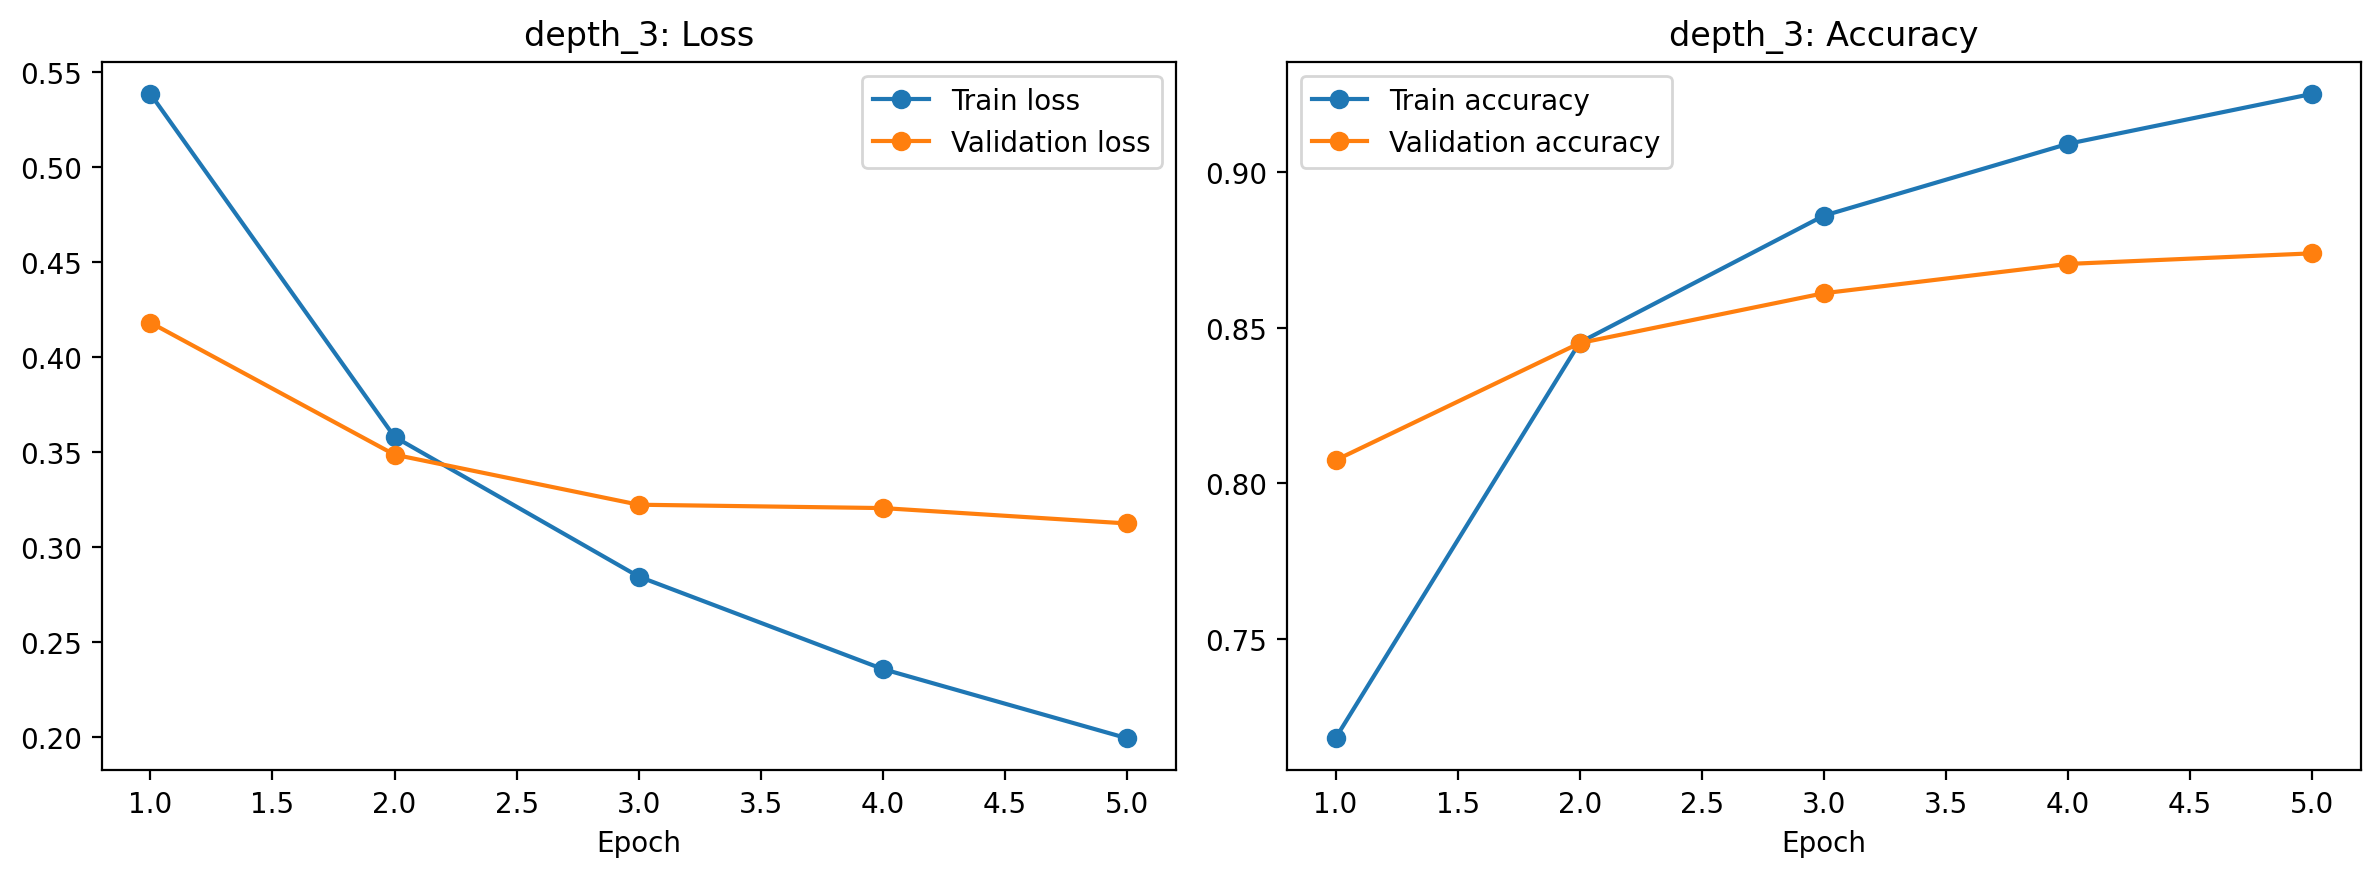

/Users/admin/Downloads/New project/checkpoints/figures/rnn_learning_curves.png


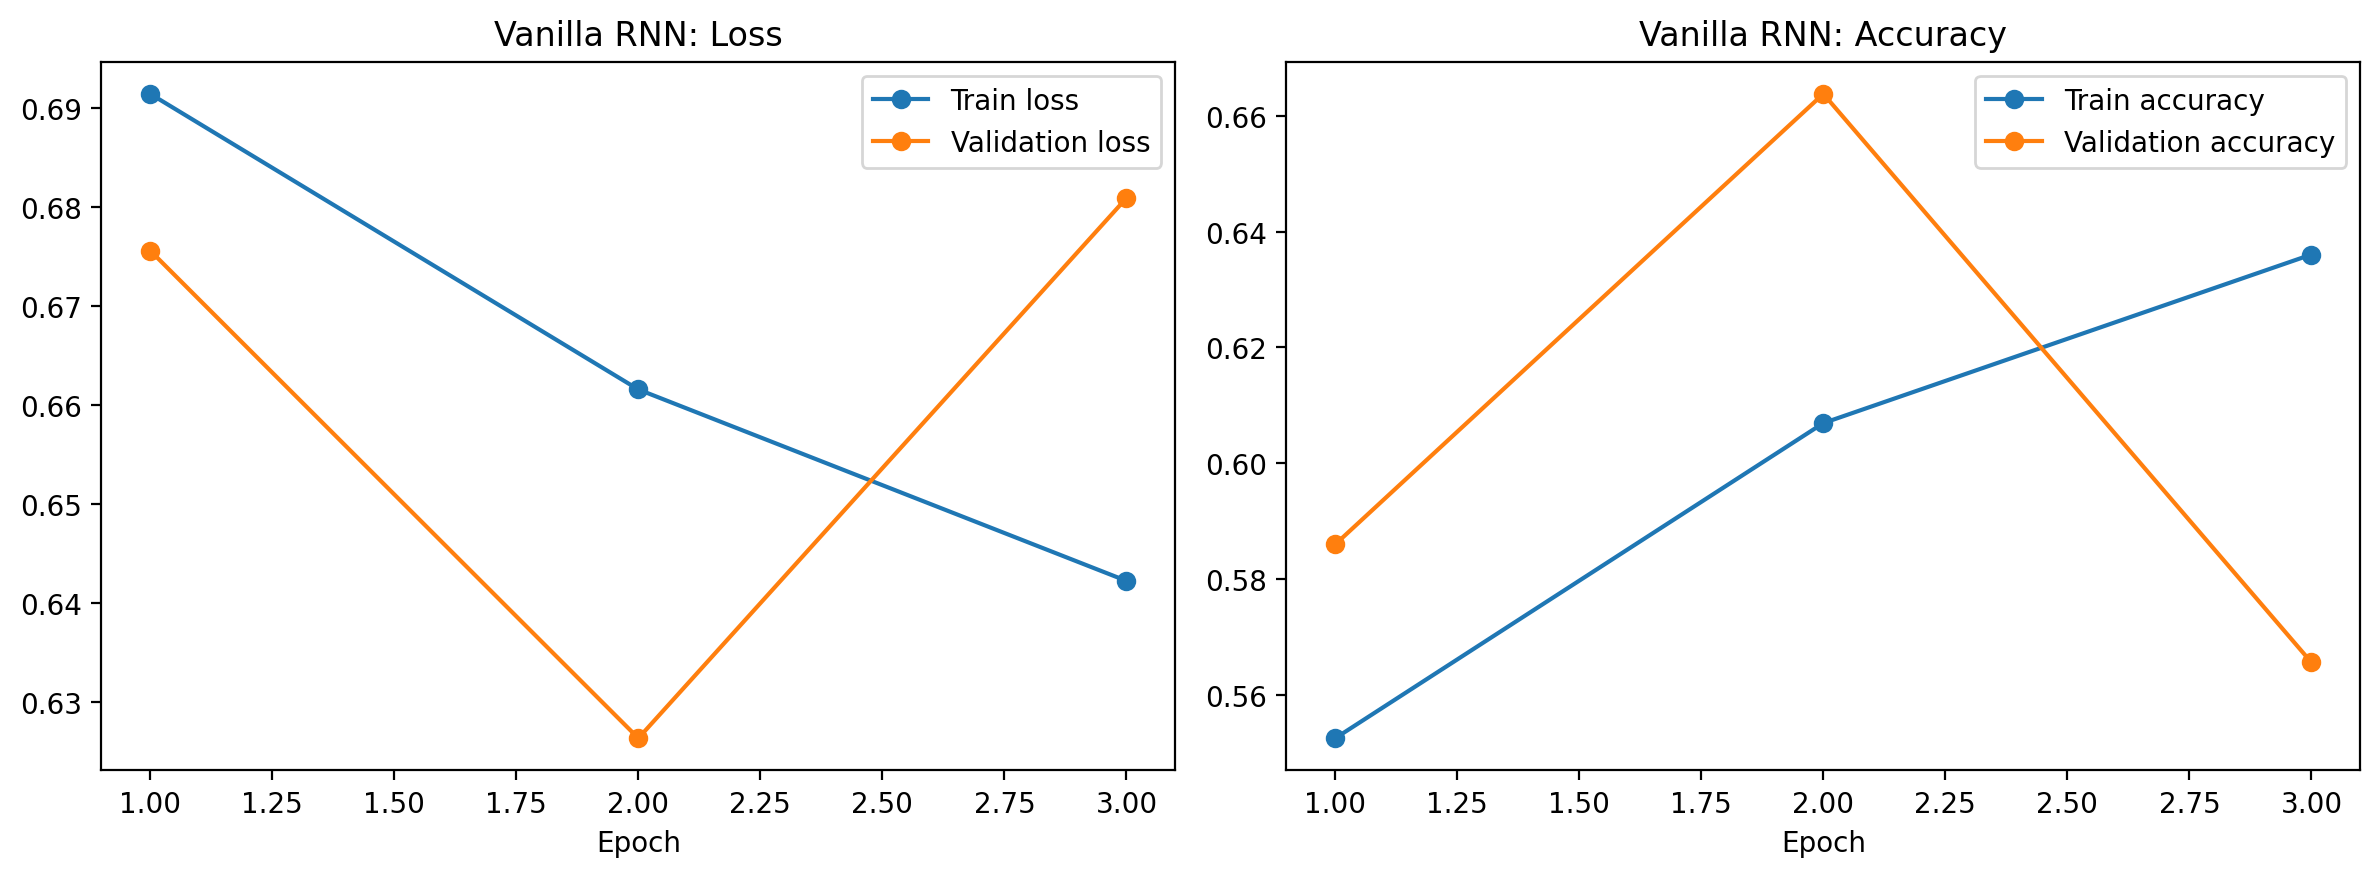

/Users/admin/Downloads/New project/checkpoints/figures/lstm_learning_curves.png


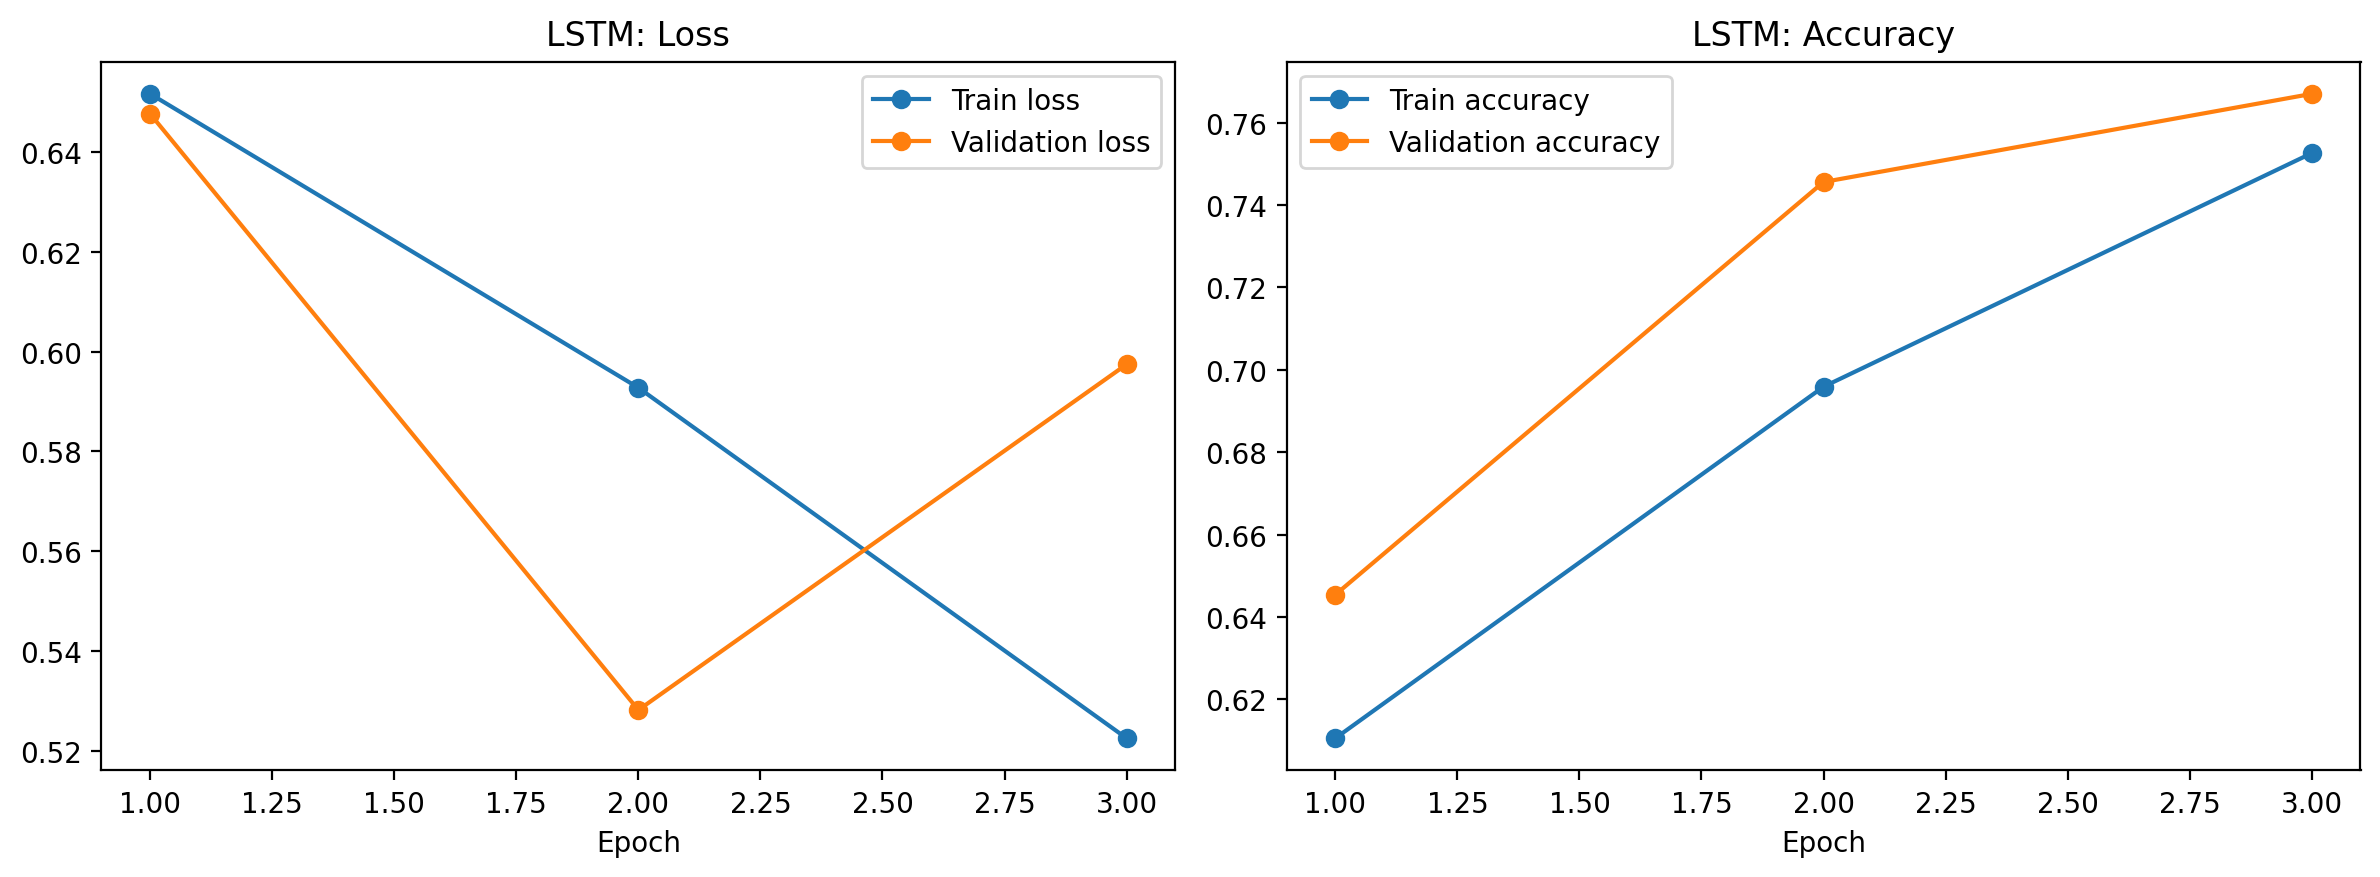

/Users/admin/Downloads/New project/checkpoints/figures/gru_learning_curves.png


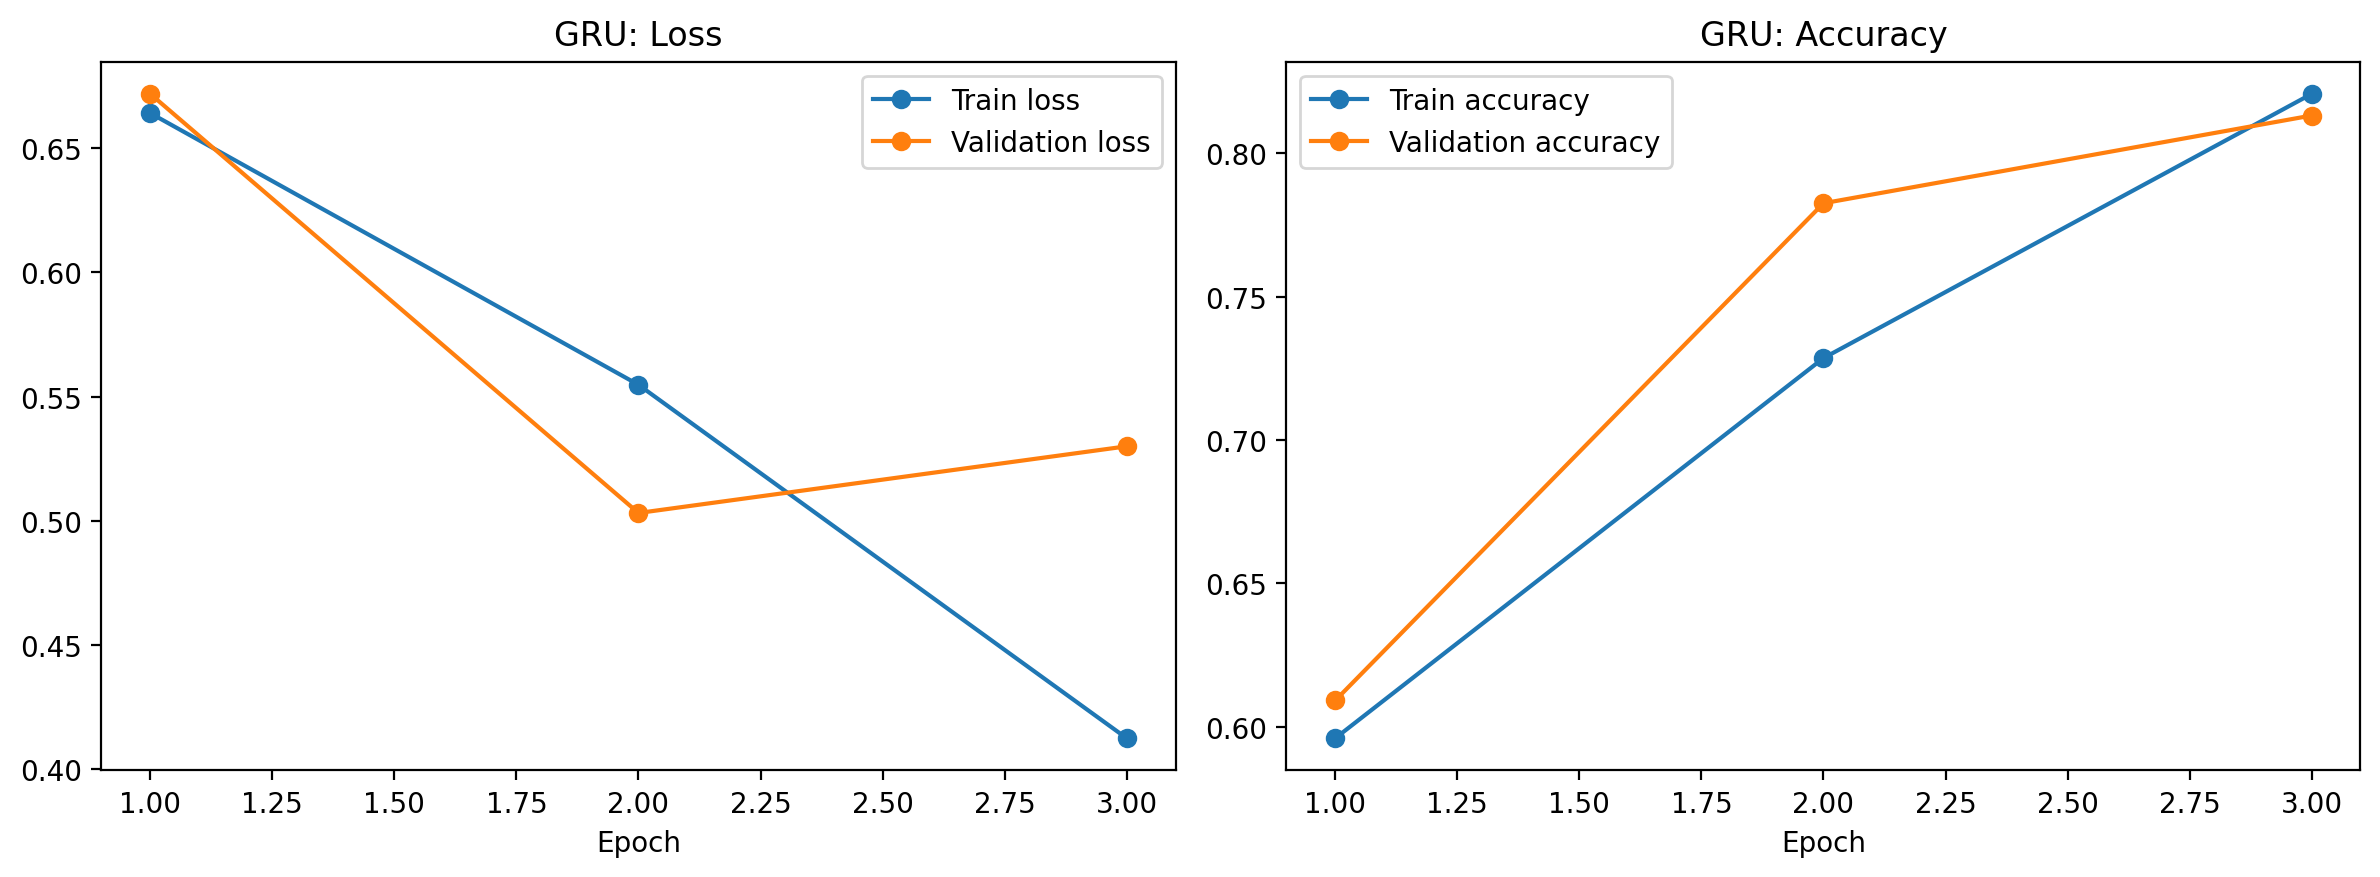

/Users/admin/Downloads/New project/checkpoints/figures/gru_emb_64_learning_curves.png


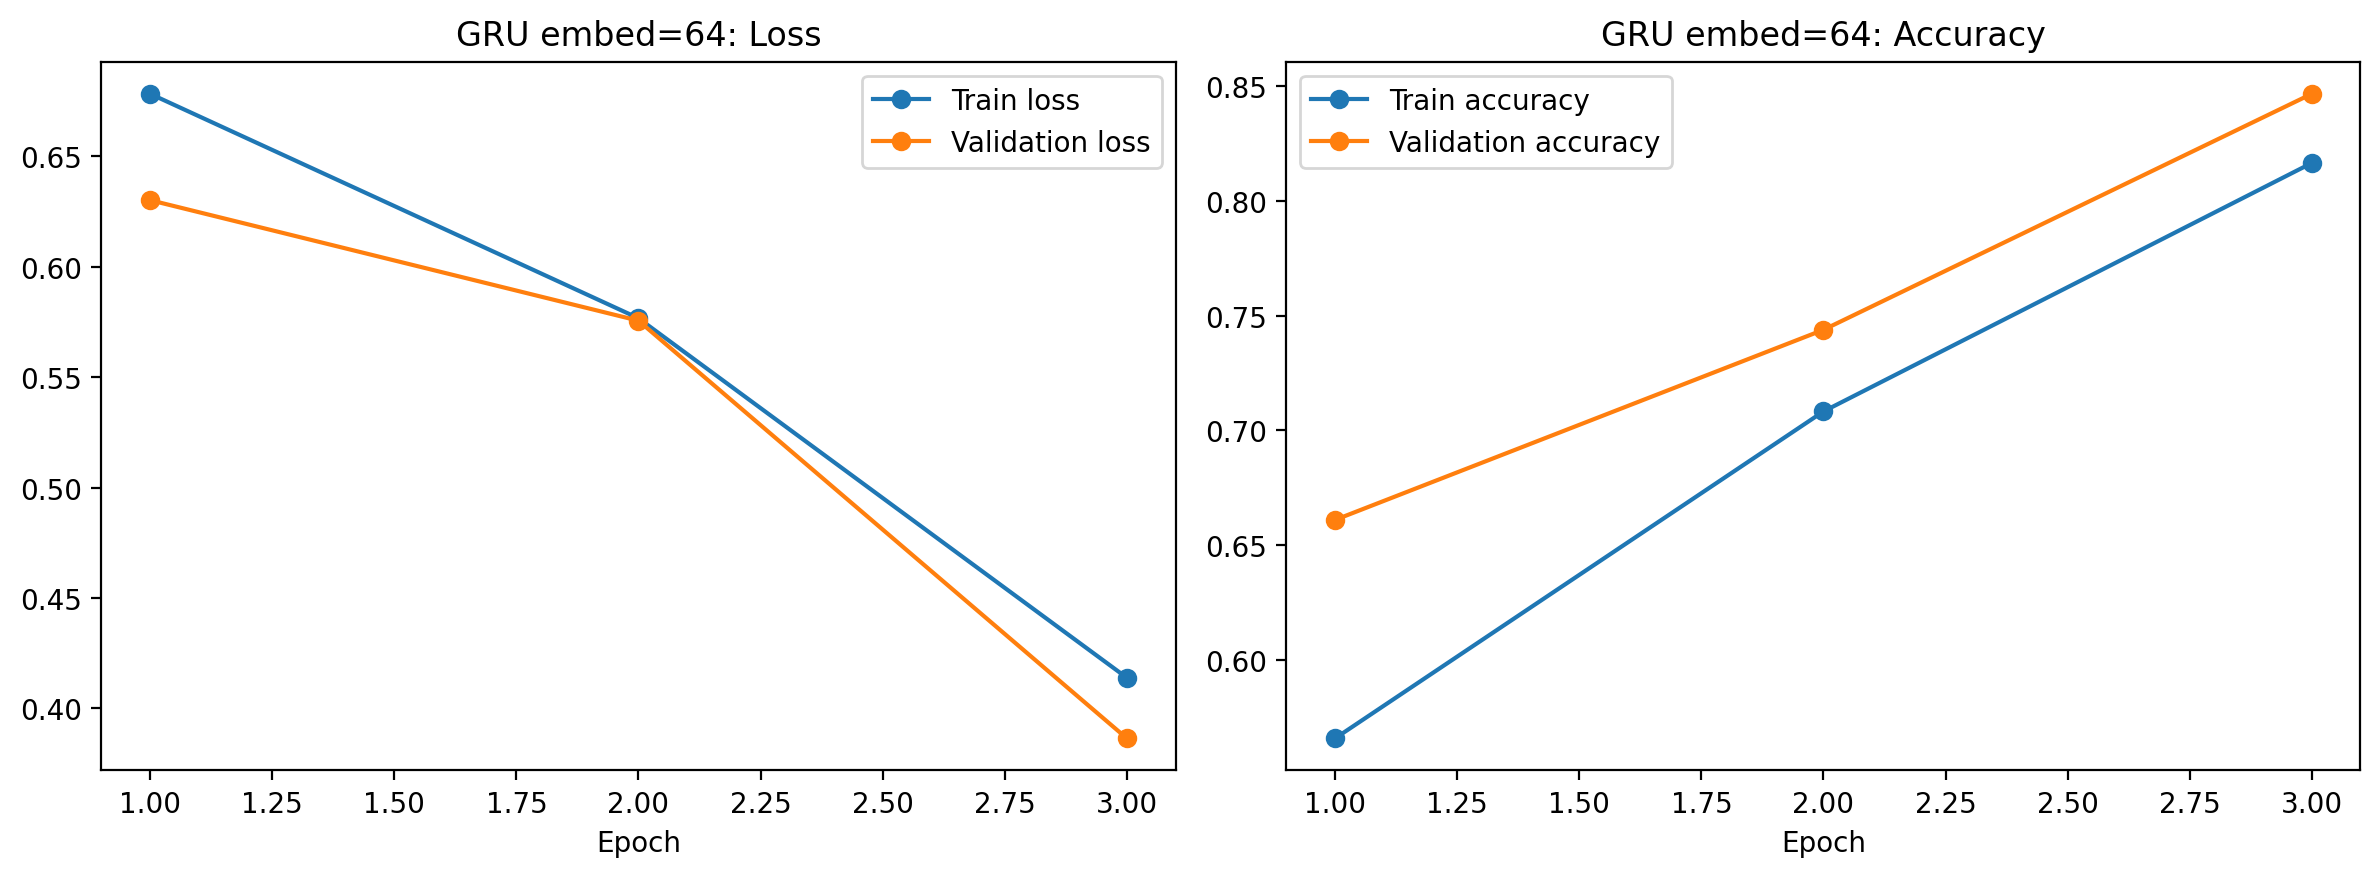

/Users/admin/Downloads/New project/checkpoints/figures/gru_emb_128_learning_curves.png


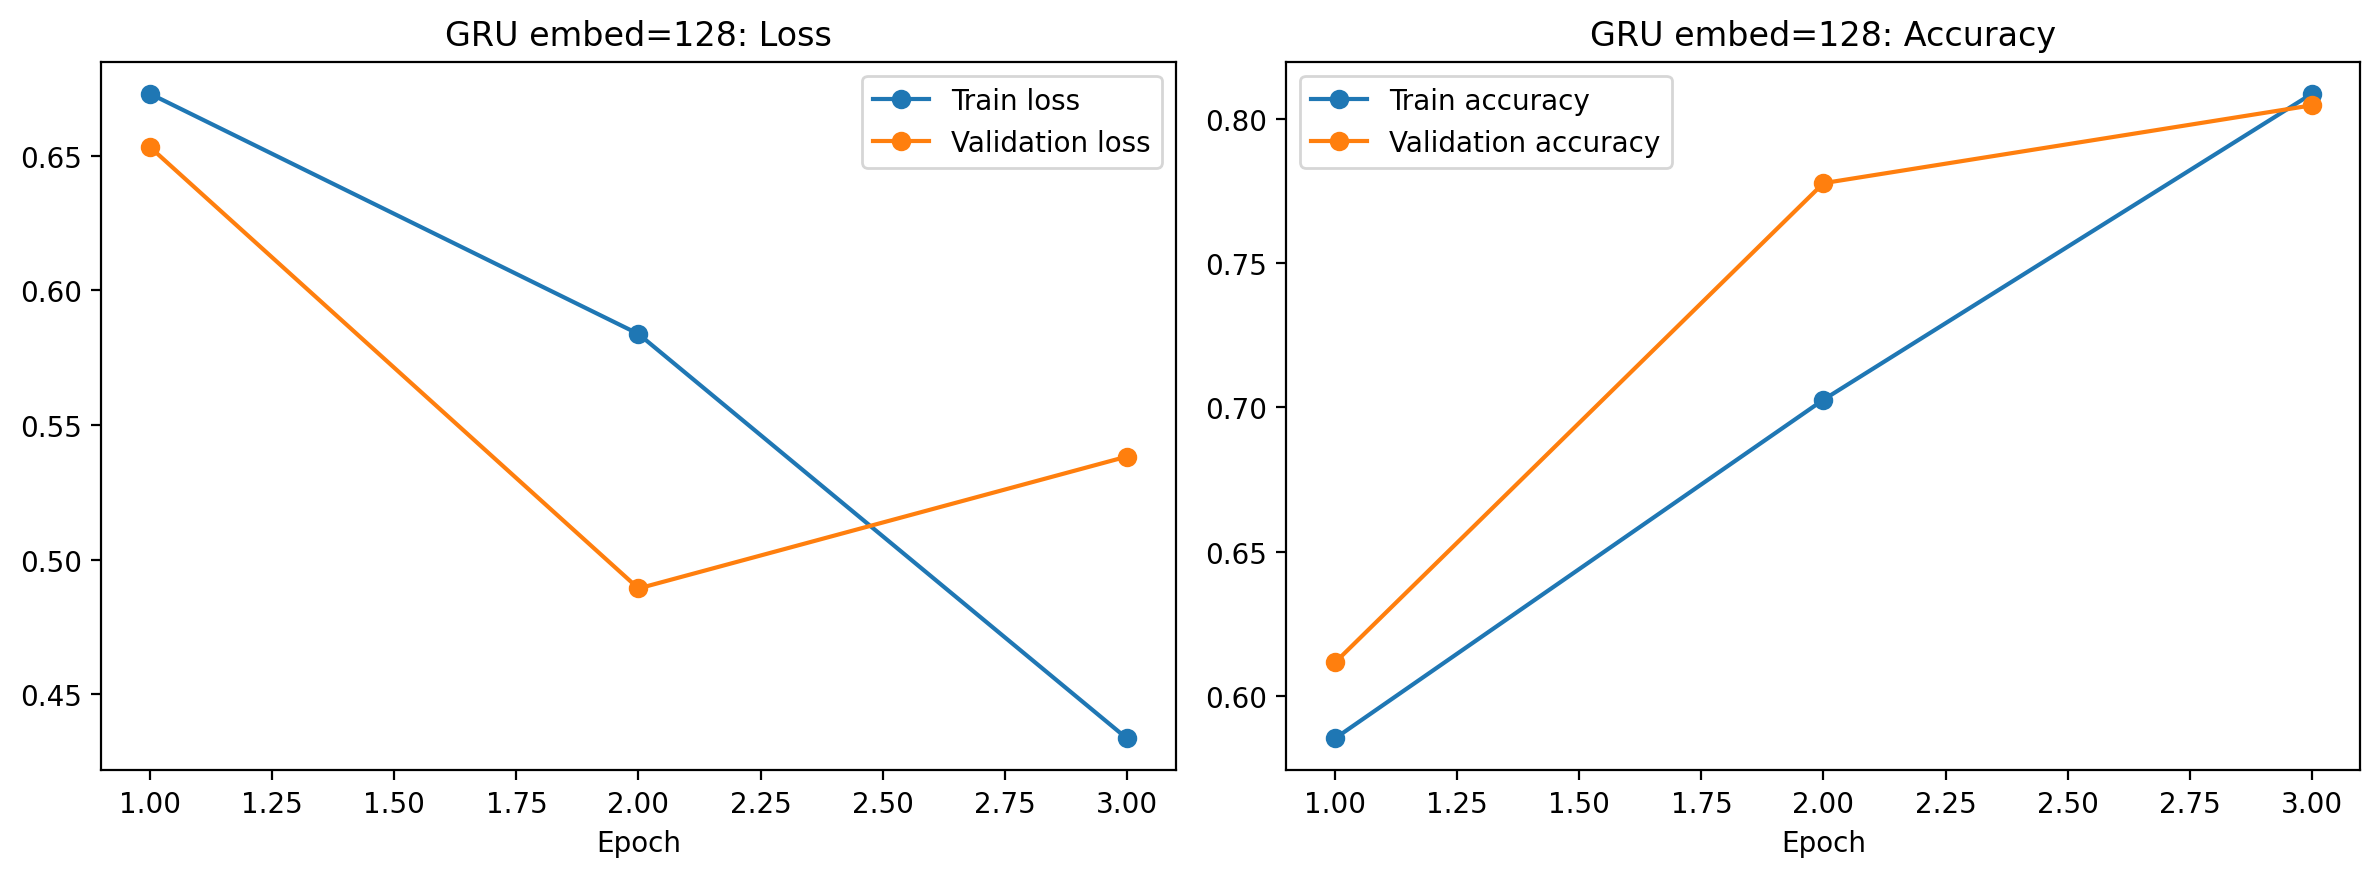

/Users/admin/Downloads/New project/checkpoints/figures/gru_emb_256_learning_curves.png


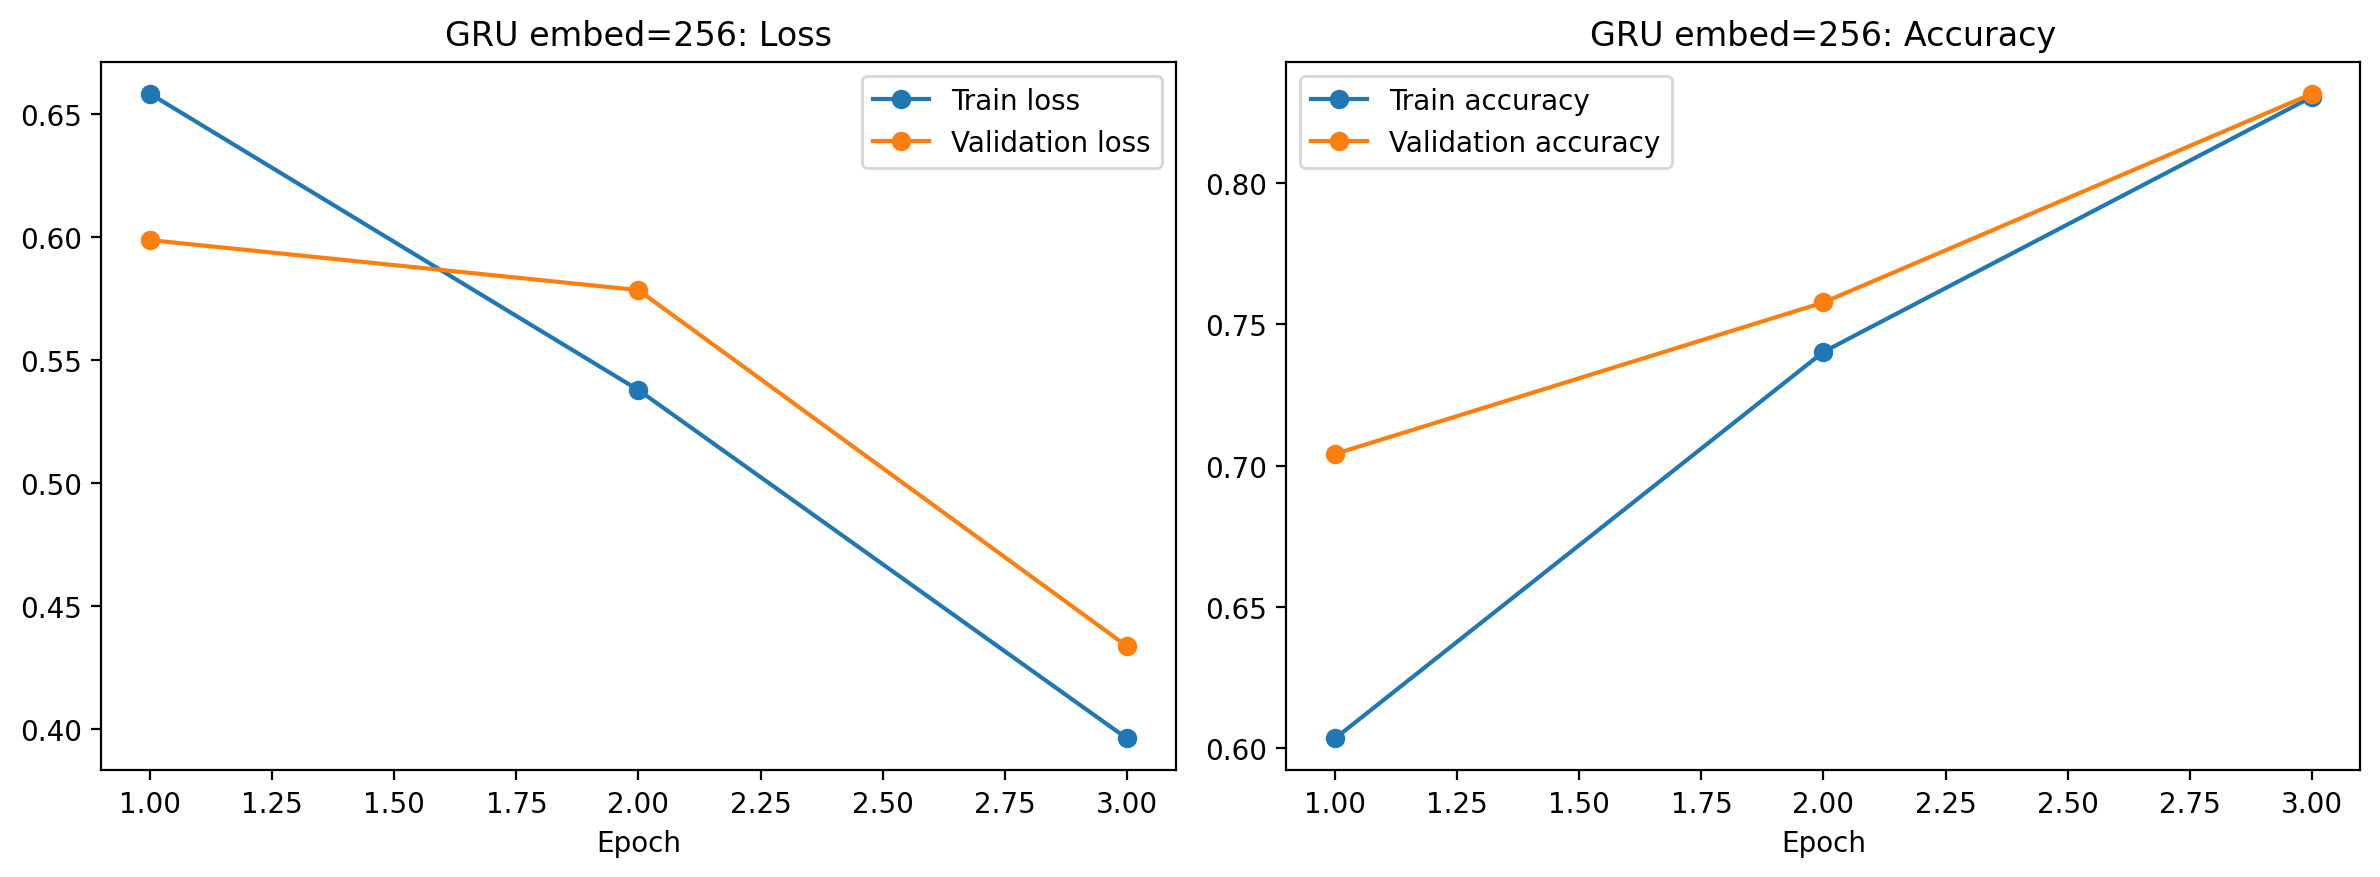

/Users/admin/Downloads/New project/checkpoints/figures/gru_1layer_learning_curves.png


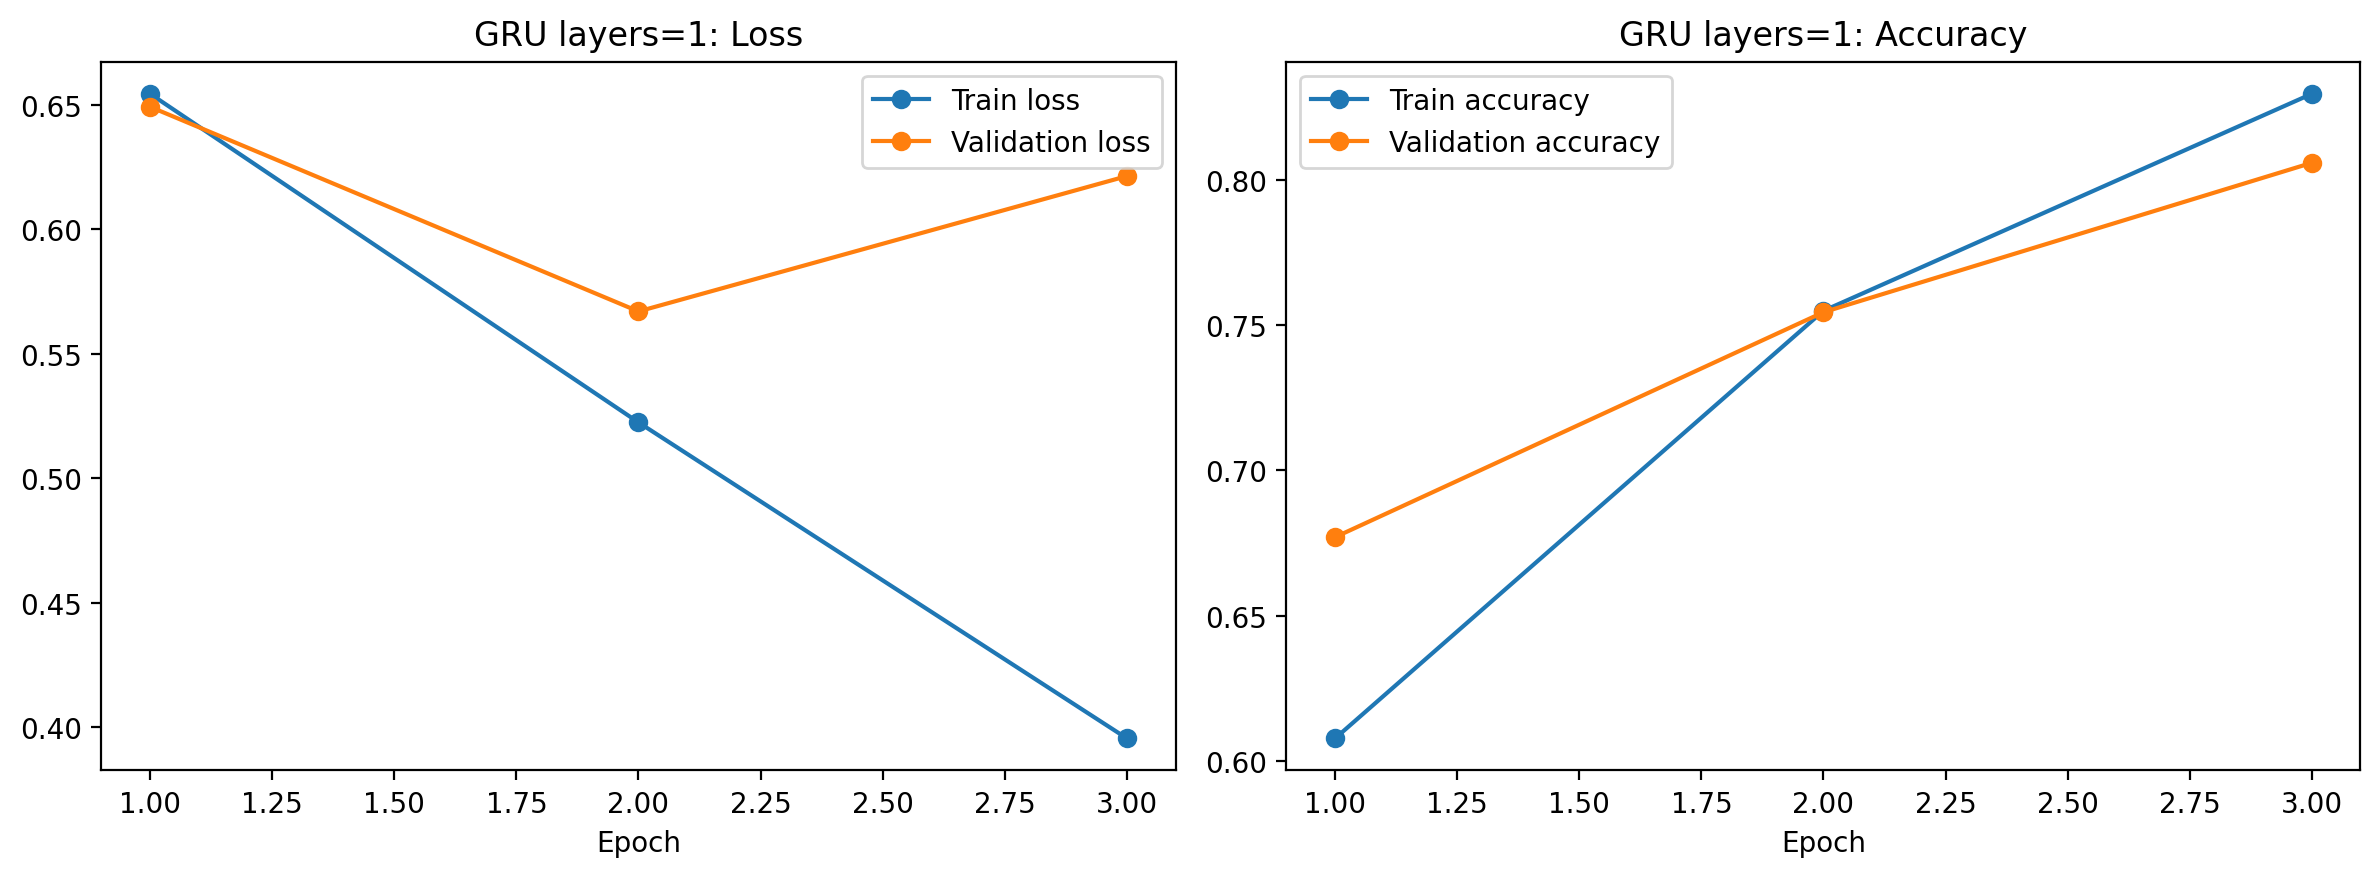

/Users/admin/Downloads/New project/checkpoints/figures/gru_2layer_learning_curves.png


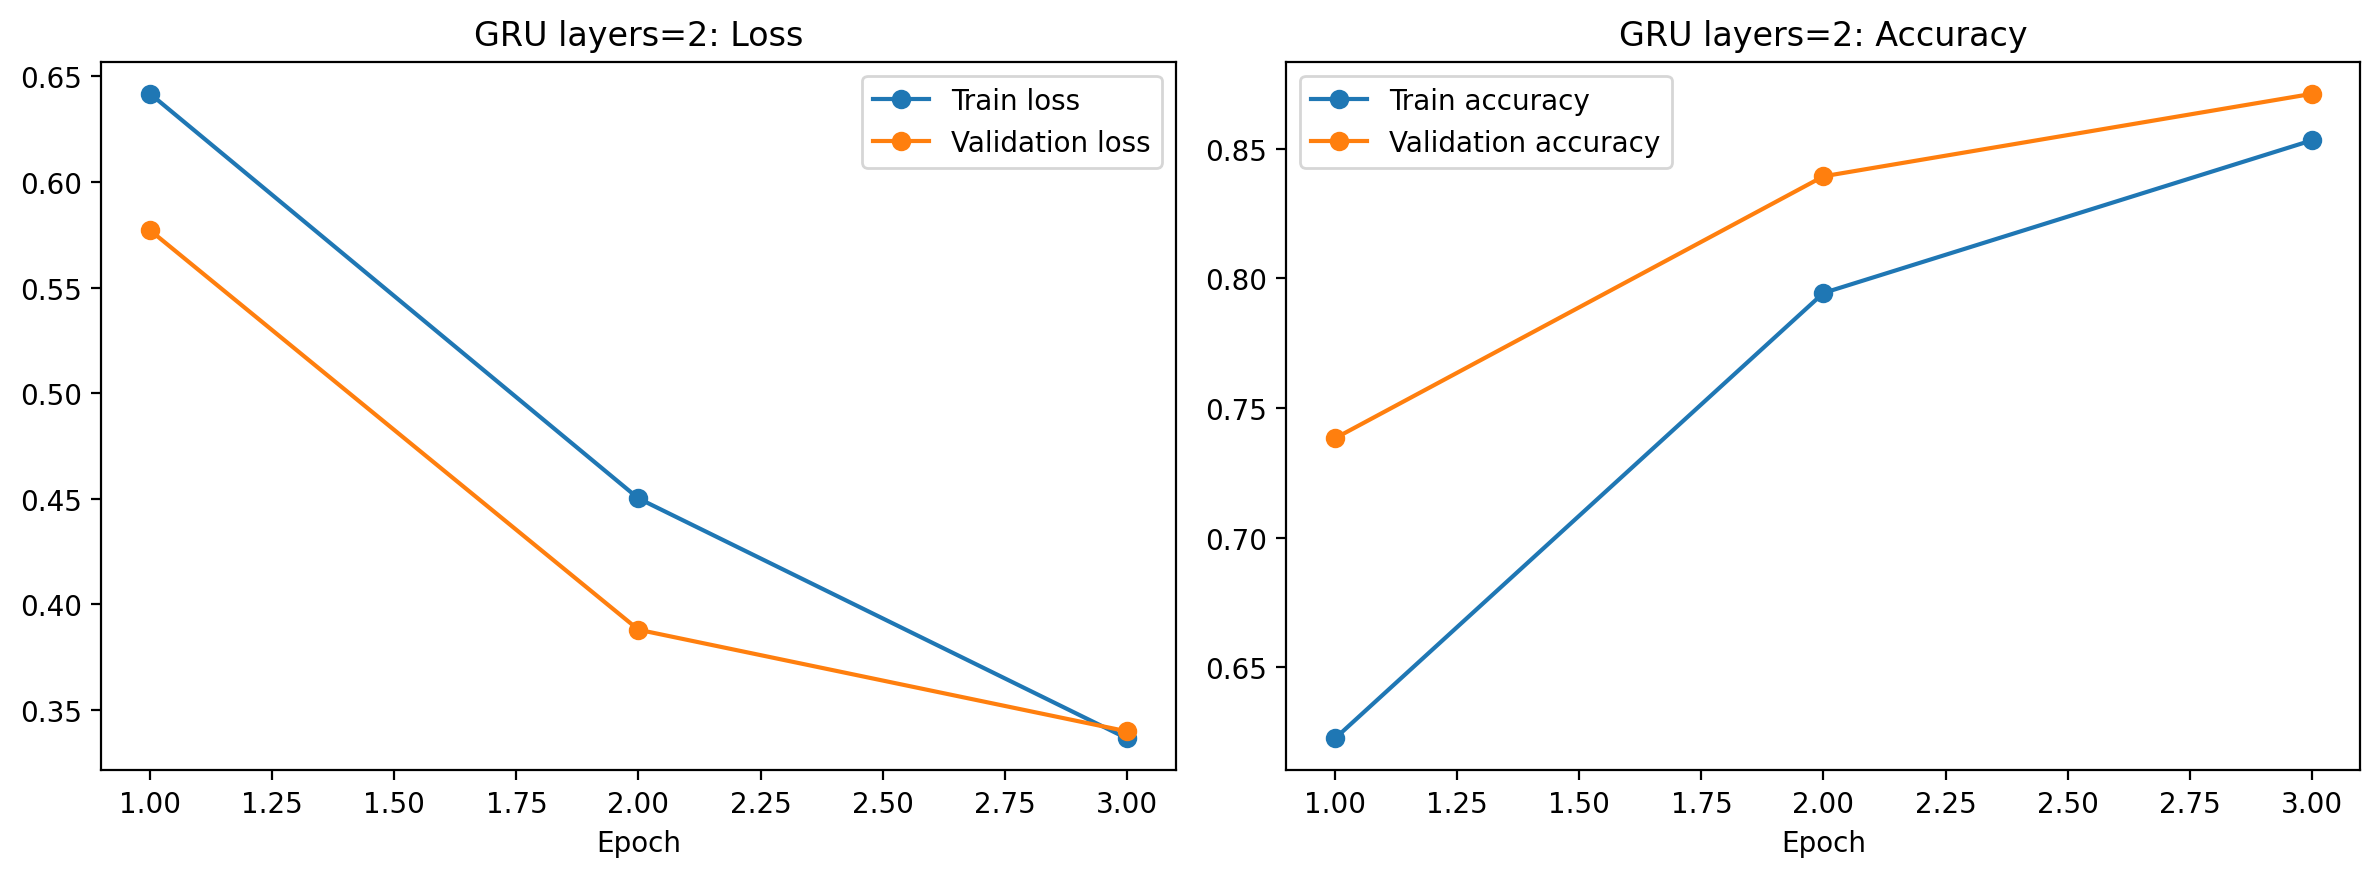

In [7]:
for figure_path in all_curve_paths:
    path = Path(figure_path)
    if path.exists():
        print(path)
        display(Image(filename=str(path)))


## Error Analysis Notes

Paste or summarize 5-10 misclassified examples from the best model here.

In [8]:
if MISCLASSIFIED_PATH.exists():
    misclassified_examples = pd.read_csv(MISCLASSIFIED_PATH).head(10).copy()
    if "pattern" not in misclassified_examples.columns:
        misclassified_examples["pattern"] = "Add linguistic pattern notes here."
else:
    misclassified_examples = pd.DataFrame(
        [
            # If the CSV is missing, rerun 03_rnn.ipynb first.
        ]
    )
misclassified_examples


,text,true_label,predicted_label,confidence_negative,confidence_positive,is_correct,pattern
0,this film was made in saskatchewan and manitob...,0,1,0.007324,0.992676,0,Add linguistic pattern notes here.
1,this is a baffling film the beauty in sexual r...,0,1,0.008520,0.991480,0,Add linguistic pattern notes here.
2,ray bradbury run and hide this tacky film vers...,0,1,0.008527,0.991473,0,Add linguistic pattern notes here.
3,i considered myself to be quite melancholy esp...,0,1,0.008882,0.991118,0,Add linguistic pattern notes here.
4,very serious spoilers this movie was a huge di...,0,1,0.009219,0.990781,0,Add linguistic pattern notes here.
5,i first saw the live musical at the denver cen...,0,1,0.009437,0.990563,0,Add linguistic pattern notes here.
6,this has to be one of the all time greatest ho...,0,1,0.009567,0.990433,0,Add linguistic pattern notes here.
7,the film heaven's gate was a good view althoug...,0,1,0.009591,0.990409,0,Add linguistic pattern notes here.
8,this movie is a rather odd mix of musical roma...,0,1,0.009653,0.990347,0,Add linguistic pattern notes here.
9,the ultimate goal of big brother that we know ...,0,1,0.009752,0.990248,0,Add linguistic pattern notes here.
